1.Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # 4. Create masks to separate normal data from outliers
    outlier_mask = (df[column] < lower_bound) | (df[column] > upper_bound)

    # 5. Split the dataframe
    outliers_df = df[outlier_mask]
    cleaned_df = df[~outlier_mask]

    print(f"--- IQR Outlier Summary for '{column}' ---")
    print(f"Lower Bound: {lower_bound:.2f} | Upper Bound: {upper_bound:.2f}")
    print(f"Identified Outliers: {len(outliers_df)} rows out of {len(df)}\n")
    return outliers_df 


2.EDA

In [3]:
df = pd.read_excel('../data/cleaned_data.xlsx')
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
df.mean(numeric_only=True)

Quantity          2.945833
UnitPrice       356.412750
ItemsInCart       5.485000
TotalPrice     1053.968300
dtype: float64

In [5]:
df.median(numeric_only=True)

Quantity         3.000
UnitPrice      364.210
ItemsInCart      5.000
TotalPrice     823.615
dtype: float64

In [6]:
df.count()

OrderID            1200
Date               1200
CustomerID         1200
Product            1200
Quantity           1200
UnitPrice          1200
ShippingAddress    1200
PaymentMethod      1200
OrderStatus        1200
TrackingNumber     1200
ItemsInCart        1200
CouponCode         1200
ReferralSource     1200
TotalPrice         1200
dtype: int64

Trends

<Axes: xlabel='Date'>

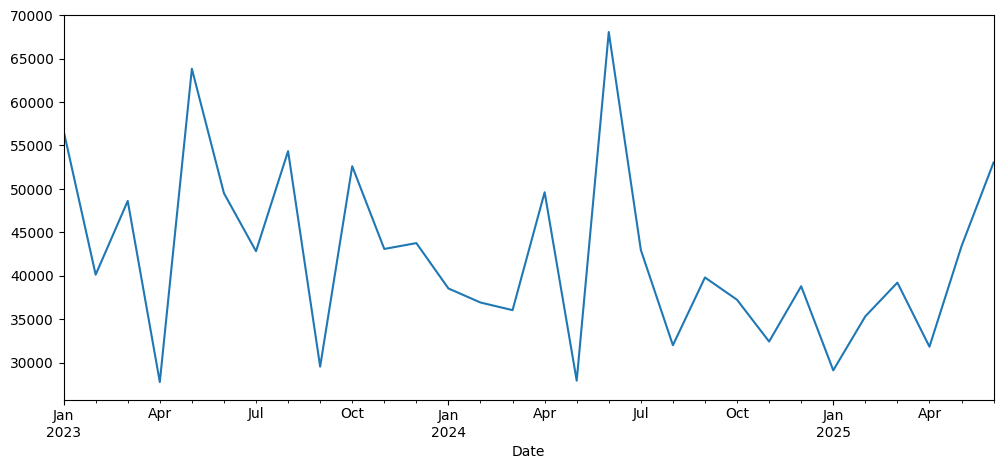

In [7]:
#1. Monthly Sales Trend
df['Date'] = pd.to_datetime(df['Date'])

monthly_sales = df.groupby(
    df['Date'].dt.to_period('M')
)['TotalPrice'].sum()

monthly_sales.plot(figsize=(12,5))

In [8]:
#2. Most Sold Products
df['Product'].value_counts()

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

In [9]:
#3. Highest Revenue Products
df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64

Note : Chairs generated the highest total revenue among all products.

<Axes: xlabel='ReferralSource'>

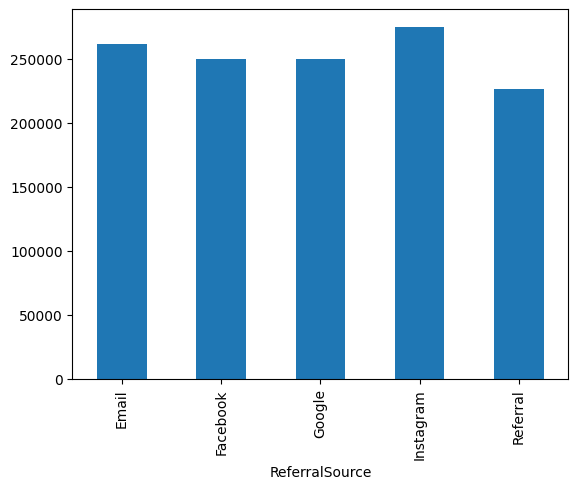

In [10]:
# 5. Sales by Marketing Source
df.groupby('ReferralSource')['TotalPrice'].sum().plot(kind='bar')

C:\Users\moham\AppData\Local\Temp\ipykernel_6924\3087337915.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='OrderStatus', ax=axes[0], palette='Blues_r', order=df['OrderStatus'].value_counts().index)
C:\Users\moham\AppData\Local\Temp\ipykernel_6924\3087337915.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='PaymentMethod', ax=axes[1], palette='Purples_r', order=df['PaymentMethod'].value_counts().index)


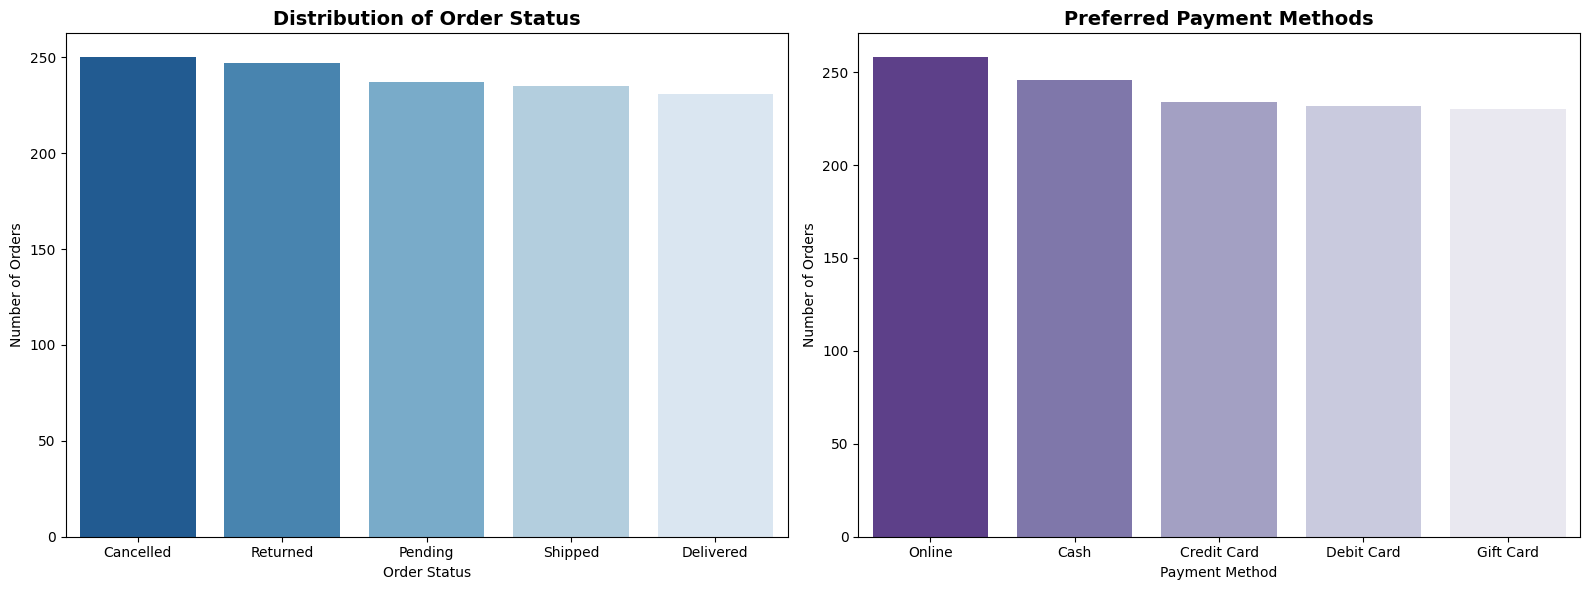

In [19]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Order Status Distribution
sns.countplot(data=df, x='OrderStatus', ax=axes[0], palette='Blues_r', order=df['OrderStatus'].value_counts().index)
axes[0].set_title('Distribution of Order Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Order Status')
axes[0].set_ylabel('Number of Orders')

# Payment Method Distribution
sns.countplot(data=df, x='PaymentMethod', ax=axes[1], palette='Purples_r', order=df['PaymentMethod'].value_counts().index)
axes[1].set_title('Preferred Payment Methods', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Payment Method')
axes[1].set_ylabel('Number of Orders')

plt.tight_layout()
plt.show()

**Payment & Logistics:** The distribution charts visualize customer behavior, showcasing which payment channels dominate, helping logistics optimize for high-demand statuses.

Outliers

In [11]:
for col in ['Quantity', 'UnitPrice', 'TotalPrice']:
    detect_outliers_iqr(df, col)

--- IQR Outlier Summary for 'Quantity' ---
Lower Bound: -1.00 | Upper Bound: 7.00
Identified Outliers: 0 rows out of 1200

--- IQR Outlier Summary for 'UnitPrice' ---
Lower Bound: -317.20 | Upper Bound: 1024.83
Identified Outliers: 0 rows out of 1200

--- IQR Outlier Summary for 'TotalPrice' ---
Lower Bound: -1341.41 | Upper Bound: 3330.41
Identified Outliers: 8 rows out of 1200



Note : Outlier analysis using the IQR method identified 8 outliers in the `TotalPrice` column out of 1200 transactions. All detected outliers had values exceeding the upper bound of 3330.41. Most of these transactions were associated with high-value electronic products such as laptops, tablets, monitors, and printers, typically purchased in quantities of 5 units. Since these records follow logical pricing patterns, they are considered legitimate high-value purchases rather than data entry errors.


In [14]:
# 1. Financial Forensics: Net vs Gross Revenue
print("--- Financial Forensics: Net vs Gross Revenue ---")

# Filtering only successful transactions (Delivered and Shipped)
successful_orders = df[df['OrderStatus'].isin(['Delivered', 'Shipped'])]

# Calculating metrics
gross_revenue = df['TotalPrice'].sum()
net_revenue = successful_orders['TotalPrice'].sum()
lost_revenue = gross_revenue - net_revenue
loss_percentage = (lost_revenue / gross_revenue) * 100

print(f"Gross Revenue (Total Sales): ${gross_revenue:,.2f}")
print(f"Net Revenue (Actual Earned): ${net_revenue:,.2f}")
print(f"Lost Revenue (Cancelled/Returned): ${lost_revenue:,.2f}")
print(f"Revenue Loss Rate: {loss_percentage:.2f}%")

--- Financial Forensics: Net vs Gross Revenue ---
Gross Revenue (Total Sales): $1,264,761.96
Net Revenue (Actual Earned): $488,759.90
Lost Revenue (Cancelled/Returned): $776,002.06
Revenue Loss Rate: 61.36%


**Revenue Leakage:** There is a significant gap between Gross Revenue and Net Revenue due to high rates of `Cancelled` and `Returned` orders. This highlights a operational vulnerability that requires investigation (e.g., shipping delays or product description mismatches).

In [15]:
# 2. Marketing ROI: Coupon Impact Analysis
print("--- Marketing ROI: Coupon Impact Analysis ---")

# Grouping by Coupon Code to see the average order value and total quantity sold
coupon_analysis = df.groupby('CouponCode').agg(
    Average_Order_Value=('TotalPrice', 'mean'),
    Total_Quantity_Sold=('Quantity', 'sum'),
    Transaction_Count=('OrderID', 'count')
).sort_values(by='Average_Order_Value', ascending=False)

print(coupon_analysis)

--- Marketing ROI: Coupon Impact Analysis ---
            Average_Order_Value  Total_Quantity_Sold  Transaction_Count
CouponCode                                                             
FREESHIP            1070.405719                  914                313
SAVE10              1065.874196                  844                286
No Coupon           1043.370259                  941                309
WINTER15            1035.902534                  836                292


**Coupon Strategy:** Certain promotional codes successfully drive a higher *Average Order Value (AOV)* compared to organic purchases (`No Coupon`), proving that the current incentive structure encourages larger basket sizes.